# 03 — Mean Reversion Research (Example)

Compares three mean-reversion indicators — RSI, Bollinger %b, and a rolling
z-score — on the same ETF universe, then evaluates the z-score strategy
end-to-end through the backtest engine.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from quantlab.config import ExperimentConfig
from quantlab.data.loader import DataLoader
from quantlab.data.base import price_matrix
from quantlab.features.mean_reversion import rolling_zscore, rsi, bollinger_bands
from quantlab.backtesting.runner import run_backtest_from_config

config = ExperimentConfig.from_yaml("../configs/mean_reversion_etfs.yaml")
data, report = DataLoader().load(config)
prices = price_matrix(data)
spy = prices["SPY"].dropna()
print(report.summary())


DataQualityReport(rows=20120/20120 clean/raw, duplicates=0, invalid_prices=0, missing_values=0, gaps=0, warnings=0)


## Comparing indicators on SPY

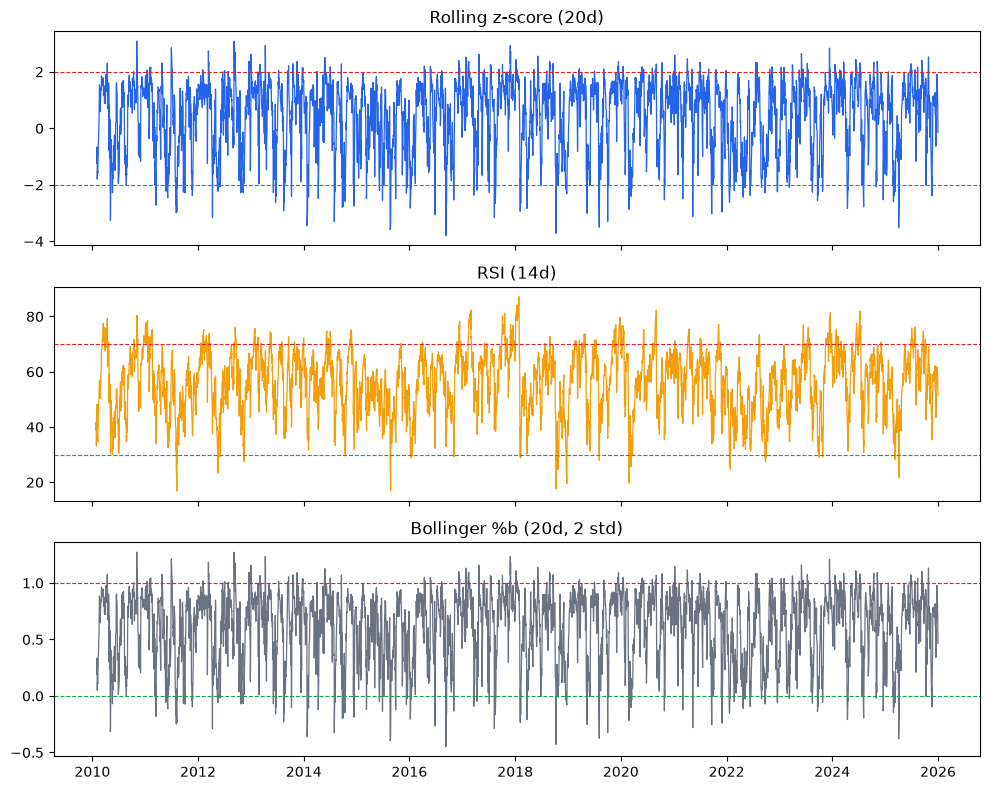

In [2]:
z = rolling_zscore(spy, window=20)
r = rsi(spy, window=14)
bb = bollinger_bands(spy, window=20, num_std=2.0)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(z.index, z.to_numpy(dtype=float), color="#2563eb", lw=0.9)
axes[0].axhline(2, color="#dc2626", lw=0.8, ls="--")
axes[0].axhline(-2, color="#16a34a", lw=0.8, ls="--")
axes[0].set_title("Rolling z-score (20d)")

axes[1].plot(r.index, r.to_numpy(dtype=float), color="#f59e0b", lw=0.9)
axes[1].axhline(70, color="#dc2626", lw=0.8, ls="--")
axes[1].axhline(30, color="#16a34a", lw=0.8, ls="--")
axes[1].set_title("RSI (14d)")

axes[2].plot(bb.index, bb["pct_b"].to_numpy(dtype=float), color="#6b7280", lw=0.9)
axes[2].axhline(1.0, color="#dc2626", lw=0.8, ls="--")
axes[2].axhline(0.0, color="#16a34a", lw=0.8, ls="--")
axes[2].set_title("Bollinger %b (20d, 2 std)")
plt.tight_layout()
plt.show()


The three indicators broadly agree on *when* SPY is stretched (their extremes
line up in time), but disagree on magnitude — this is exactly why the
strategy config exposes `entry_threshold` / `exit_threshold` as tunable
parameters (on whichever `indicator` is selected — z-score, Bollinger %B, RSI,
distance to a moving average, or percentile rank) rather than hard-coding
one indicator's convention.


## Full backtest: rolling z-score mean reversion

In [3]:
result = run_backtest_from_config(data, config, data_quality_report=report)
print(result.summary())


Experiment : mean_reversion_etfs
Strategy   : mean_reversion
Symbols    : SPY, QQQ, IWM, EFA, EEM
Period     : 2010-01-04 -> 2025-12-31
------------------------------------------------
Total return       :     98.69%
CAGR               :      4.39%
Volatility (ann.)  :     12.65%
Sharpe             :       0.25
Sortino            :       0.35
Calmar             :       0.13
Max drawdown       :    -34.63%
Hit rate (non-zero periods): 48.84%
Total costs (currency units): 26188.01
Number of fills    :       3351
------------------------------------------------
Beta               :       0.51
Alpha (ann.)       :     -3.34%
Information ratio  :      -0.77


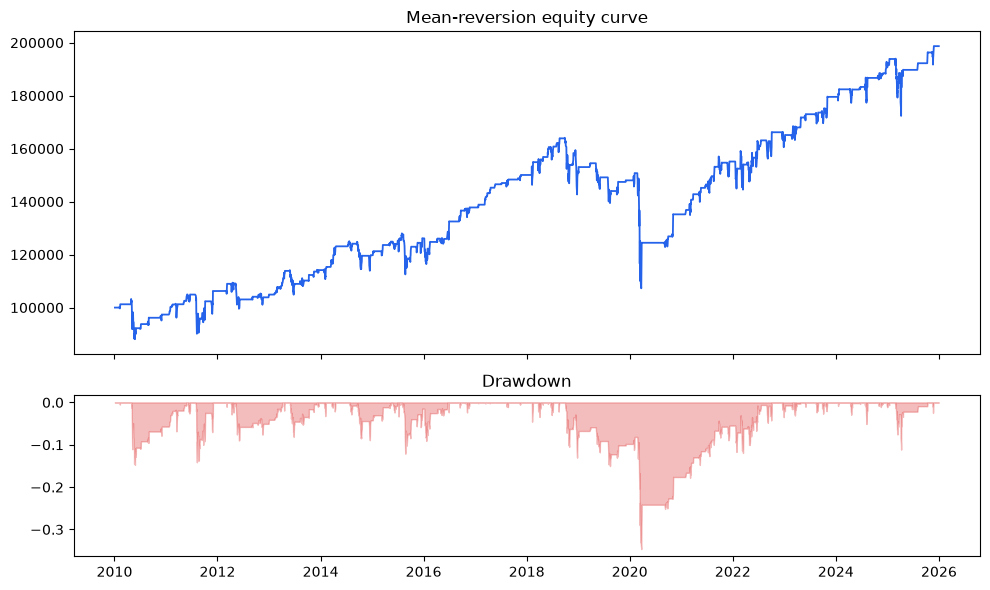

In [4]:
from quantlab.risk.drawdown import drawdown_series
dd = drawdown_series(result.equity_curve)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(result.equity_curve.index, result.equity_curve.to_numpy(dtype=float), color="#2563eb", lw=1.3)
axes[0].set_title("Mean-reversion equity curve")
axes[1].fill_between(dd.index, dd.to_numpy(dtype=float), 0, color="#dc2626", alpha=0.3)
axes[1].set_title("Drawdown")
plt.tight_layout()
plt.show()


## Gross vs net performance

In [5]:
from quantlab.reporting.tables import gross_net_table

gross_net_table(result)


,Metric,Value
0,Gross total return,140.62%
1,Net total return,98.69%
2,Cost drag,41.92%
3,Total cost (currency units),"26,188.01"
4,Gross Sharpe,0.34
5,Net Sharpe,0.25


## Takeaways

Short-horizon mean reversion on liquid equity ETFs trades far more often than
the monthly-rebalanced momentum strategy (see the trade count above), so
transaction costs matter proportionally more here. The gross-versus-net table
above quantifies how much of the strategy's pre-cost return is lost to
transaction costs.
